In [3]:
!pip install lifelines

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'

  DEPRECATION: Building 'autograd-gamma' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'autograd-gamma'. Discussion can be found at https://github.com/pypa/pip/issues/6334



  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4048 sha256=620d137e432d77f55e3247af7d96971b9a6bce89ee34f5f149e13396577ebed0
  Stored in directory: c:\users\eceon\appdata\local\pip\cache\wheels\7e\16\46\9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma

   ---------------------------------------- 0/5 [interface-meta]
   -------- ------------------------------- 1/5 [autograd]
   -------- ------------------------------- 1/5 [autograd]
   -------- ------------------------------- 1/5 [autograd]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   -------------------------------- ------- 4/5 [lifelines]
   -------------------------------- ------- 4/5 [lifelines]
   -------------------------------- ------- 4/5 [lifelines]
   -----

In [2]:
!pip install shap xgboost

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 2.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.4/101.7 MB 11.1 MB/s eta 0:00:09
   -- ------------------------------------- 5.2/101.7 MB 12.9 MB/s eta 0:00:08
   --- ------------------------------------ 8.7/101.7 MB 13.9 MB/s eta 0:00:07
   ---- ----------------------------------- 12.3/101.7 MB 14.7 MB/s eta 0:00:07
   ------ --------------------------------- 16.0/101.7 MB 15.1 MB/s eta 0:00:06
   ------- -------------------------------- 20.2/101.7 MB 15.8 MB/s eta 0:00:06
   --------- ------------------------------ 24.9/101.7 MB 16.9 MB/s eta 0:00:05
   ----------- ---------------------------- 29.6/101.7 MB 17.6 MB/s eta 0:00:05
   ------------- -------------------------- 34.6/101.7 MB 18.1 MB/s eta 0:00:04
   --------------- ------------------------ 38.3/101.7 MB 18.

Censoring rate: 71.7% of rows are right-censored
These were the rows silently biasing your OLS coefficients.

--- MODEL DIAGNOSTIC: VIF SCORES ---
            feature         VIF
0             const  416.396799
1     Barrier_Score   11.319055
2      Danceability    1.529488
3            Energy   31.711569
4          Loudness    1.356925
5       Speechiness    1.087413
6           Valence    1.488680
7      Acousticness    1.660334
8  Instrumentalness    1.100889
9  Energy_x_Barrier   43.065536 

METHODOLOGY NOTE: Variance inflation factors indicate multicollinearity between
Energy and the interaction term; the Cox penalizer (λ=0.1) was applied to
regularize coefficient estimates.

MODEL 1: COX PROPORTIONAL HAZARDS
                   coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%  \
covariate                                                                      
Barrier_Score    -0.591      0.554                0.532                0.576   
Danceability     -0.304      0.738  

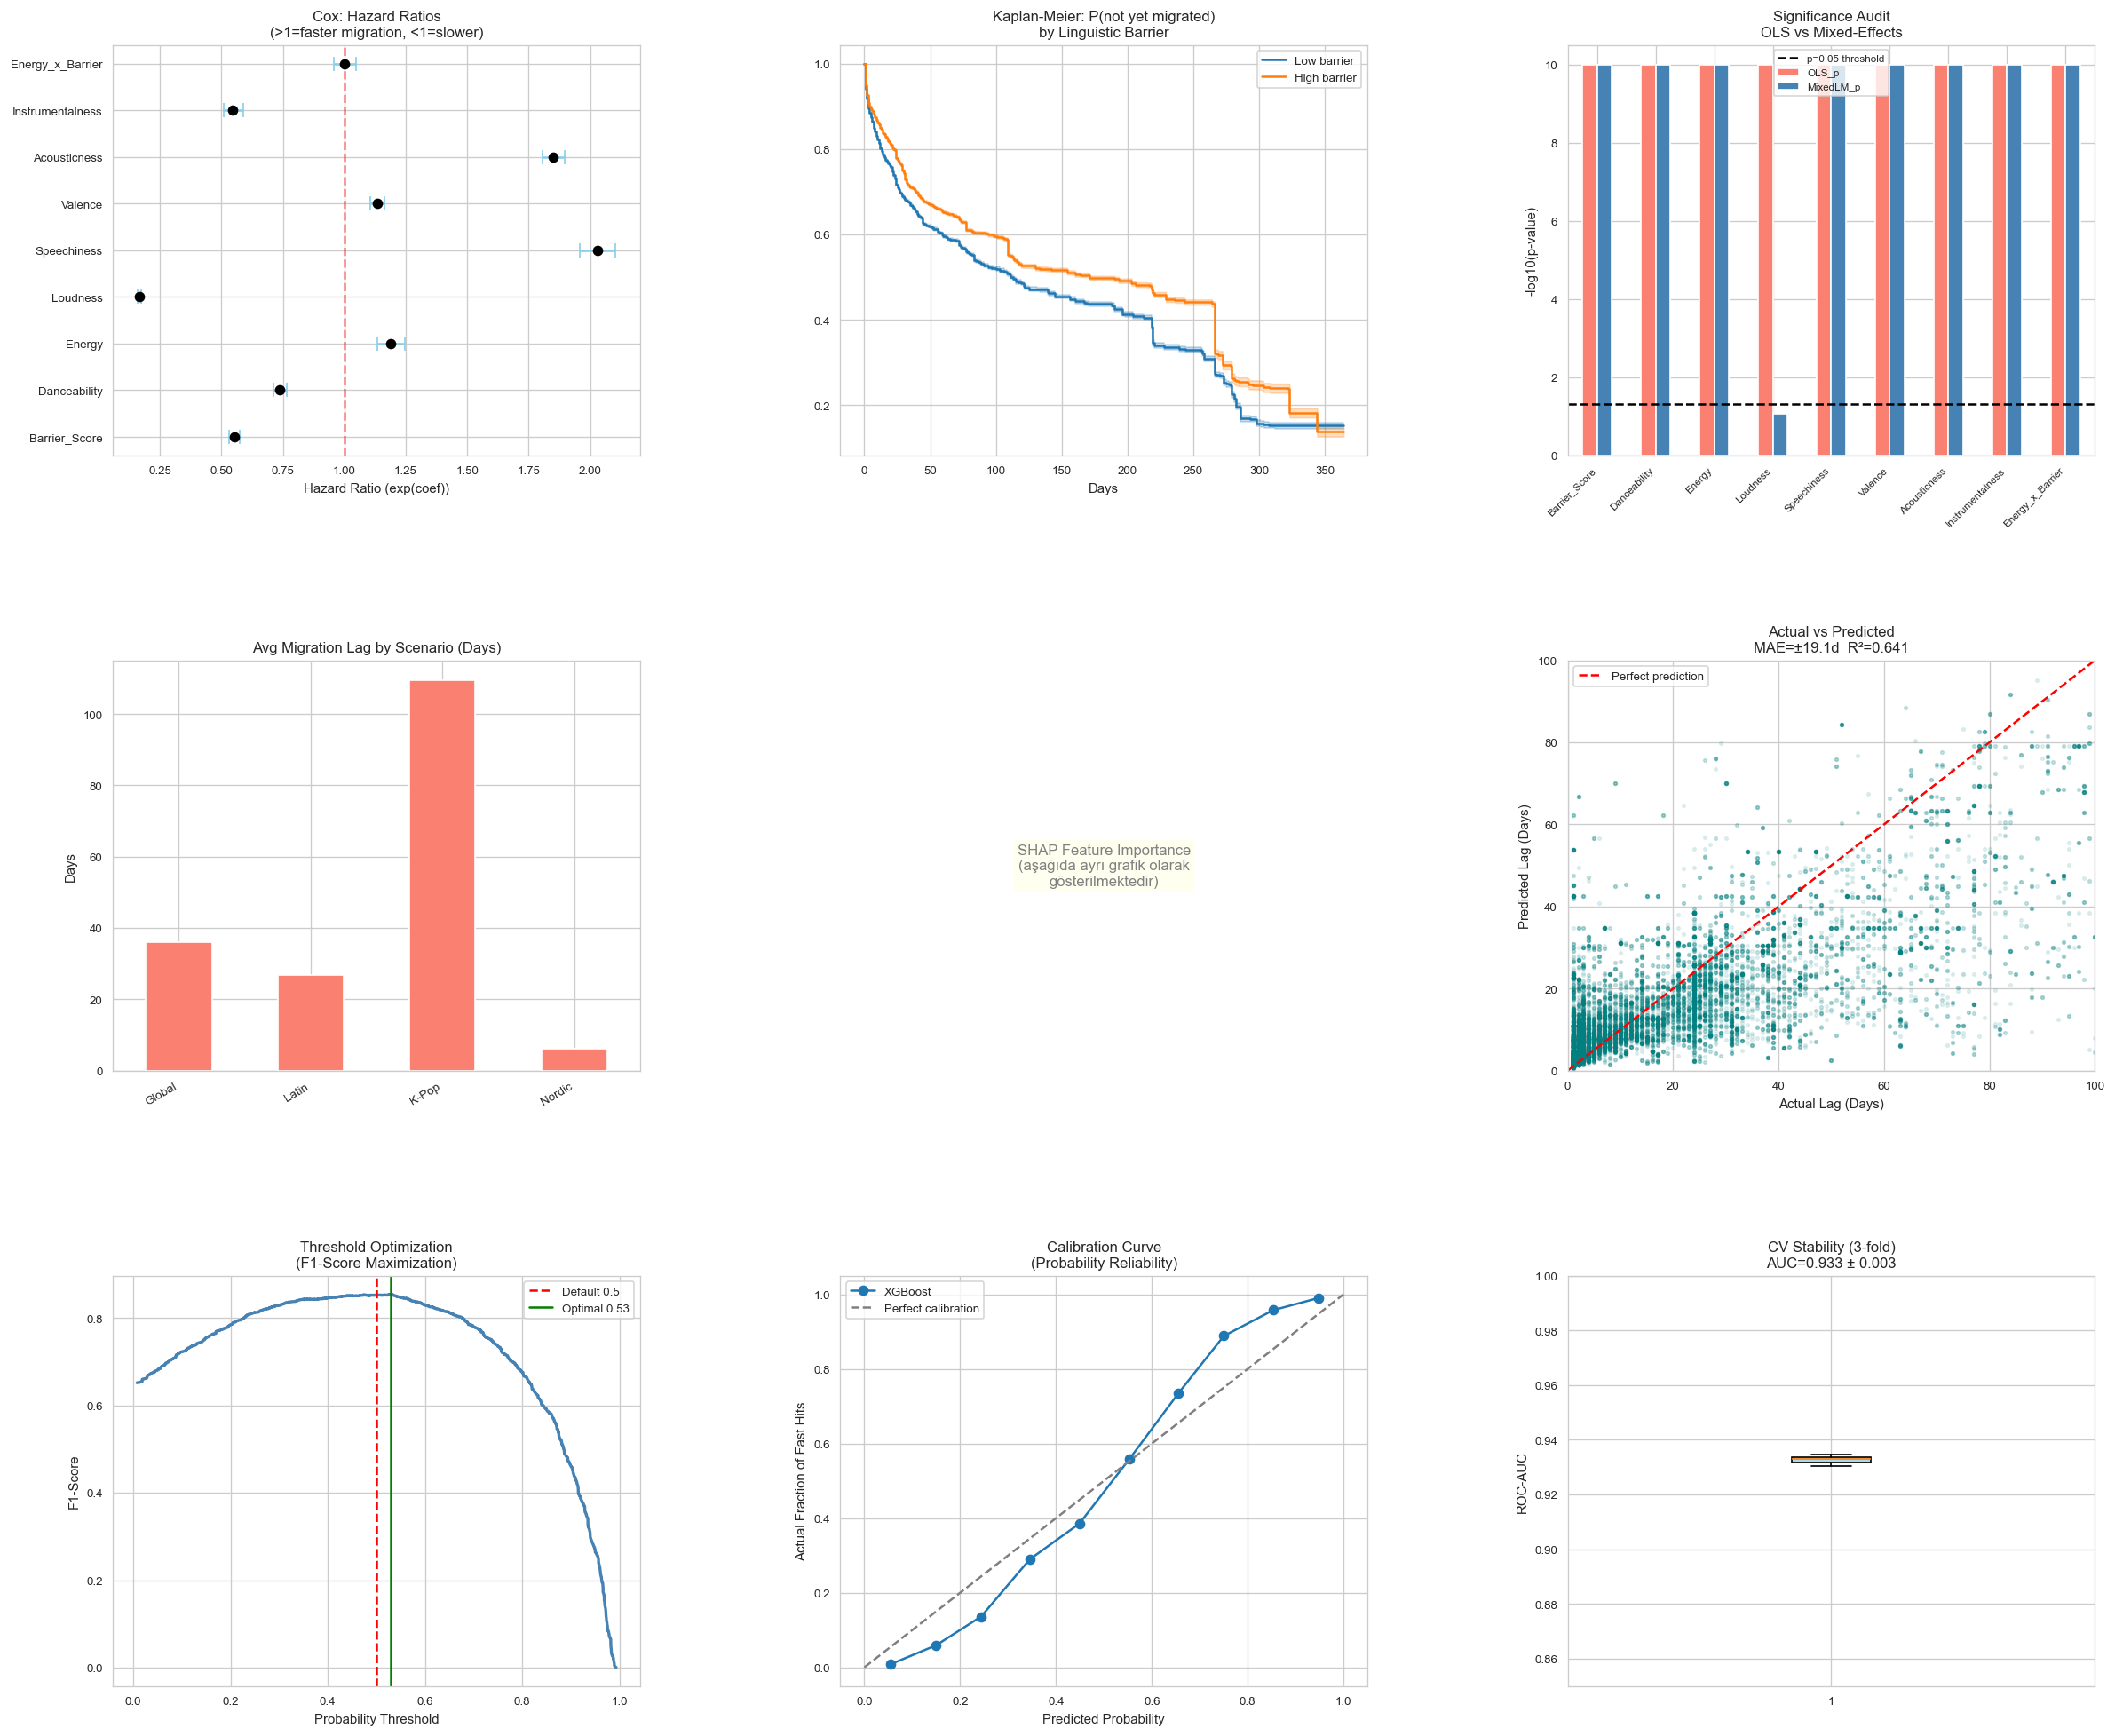

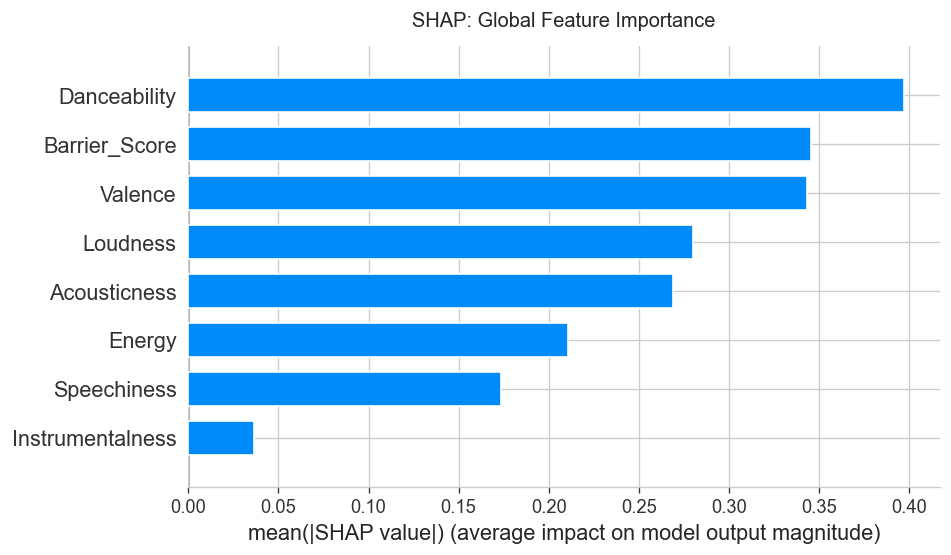

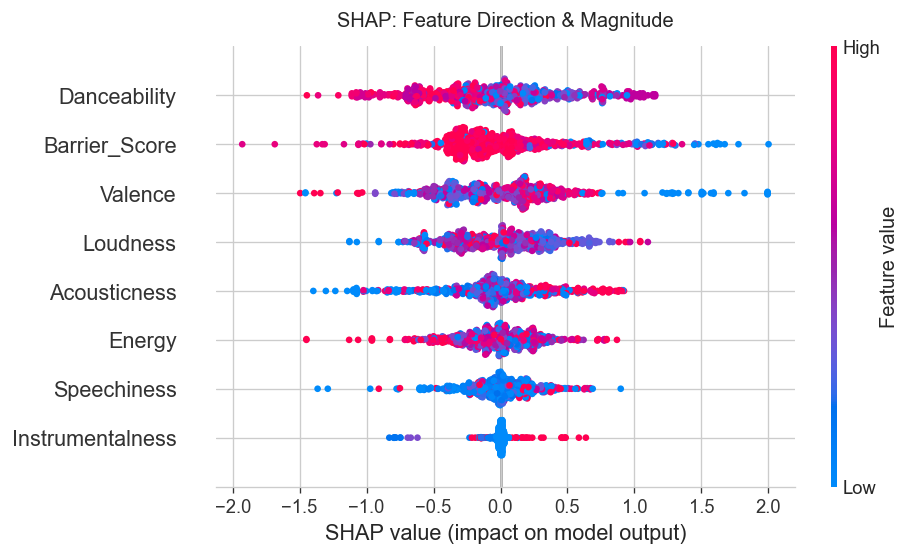


Analysis Complete.


In [14]:
# Milestone 2
import pandas as pd
import numpy as np
import pycountry
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 120,
})

# 1. SETTINGS AND FILE LOADING
CHART_FILE = 'charts.csv'
AUDIO_FILE = 'Spotify_Dataset_V3.csv'
LING_FILE = 'ling_web (1).dta'
FILTERED_OUTPUT = 'charts_2021_filtered.csv'
CHART_COLS = ['title', 'artist', 'date', 'region']

try:
    charts_df = pd.read_csv(FILTERED_OUTPUT)
    charts_df['date'] = pd.to_datetime(charts_df['date'])
except FileNotFoundError:
    chunks = pd.read_csv(CHART_FILE, chunksize=250000, usecols=CHART_COLS)
    filtered_list = [chunk[pd.to_datetime(chunk['date'], errors='coerce').dt.year == 2021] for chunk in chunks]
    charts_df = pd.concat(filtered_list)
    charts_df.to_csv(FILTERED_OUTPUT, index=False)

audio_df = pd.read_csv(AUDIO_FILE, sep=';')
ling_df = pd.read_stata(LING_FILE)

# --- STEP B: STANDARDIZATION AND CLEANING ---
def country_to_iso3(name):
    if pd.isna(name): return None
    manual_map = {'Turkey': 'TUR', 'Türkiye': 'TUR', 'United States': 'USA', 'Global': 'WLD'}
    try: return pycountry.countries.lookup(str(name).strip()).alpha_3
    except: return manual_map.get(str(name).strip(), None)

audio_df['Artist_ISO3'] = audio_df['Nationality'].apply(country_to_iso3)
charts_df['Region_ISO3'] = charts_df['region'].apply(country_to_iso3)

# --- STEP C: DATA MERGING AND FEATURE ENGINEERING ---
first_appearances = charts_df.groupby(['title', 'artist', 'Region_ISO3'])['date'].min().reset_index()
migration_df = pd.merge(first_appearances, audio_df, left_on=['title', 'artist'], right_on=['Title', 'Artists'])

home_market = migration_df[migration_df['Region_ISO3'] == migration_df['Artist_ISO3']]
home_start_dates = home_market.groupby(['title', 'artist'])['date'].min().reset_index().rename(columns={'date': 'Home_Start_Date'})

analysis_df = pd.merge(migration_df, home_start_dates, on=['title', 'artist'])
analysis_df['Migration_Lag'] = (analysis_df['date'] - analysis_df['Home_Start_Date']).dt.days
analysis_df = analysis_df[analysis_df['Migration_Lag'] > 0].copy()

# Add Linguistic Barrier
analysis_df = pd.merge(analysis_df, ling_df, left_on=['Artist_ISO3', 'Region_ISO3'], right_on=['iso_o', 'iso_d'], how='left')
analysis_df['Barrier_Score'] = 1 - (analysis_df['csl'].fillna(0) * analysis_df['lp1'].fillna(0))
 
# --- STEP D: STATISTICAL MODELING — COX PH + MIXED EFFECTS ---
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
import statsmodels.formula.api as smf
import networkx as nx
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

features = ['Barrier_Score', 'Danceability', 'Energy', 'Loudness',
            'Speechiness', 'Valence', 'Acousticness', 'Instrumentalness']

scaler = MinMaxScaler()
analysis_df[features] = scaler.fit_transform(analysis_df[features])

analysis_df['Energy_x_Barrier'] = analysis_df['Energy'] * analysis_df['Barrier_Score']
features_final = features + ['Energy_x_Barrier']

# --- CENSORING FLAG ---
STUDY_END = pd.Timestamp('2021-12-31')
if 'last_seen_date' not in analysis_df.columns:
    last_seen = charts_df.groupby(['title', 'artist'])['date'].max().reset_index()
    last_seen.columns = ['title', 'artist', 'last_seen_date']
    analysis_df = pd.merge(analysis_df, last_seen, on=['title', 'artist'], how='left')

analysis_df['event_observed'] = (analysis_df['last_seen_date'] < STUDY_END).astype(int)
analysis_df['log_lag'] = np.log1p(analysis_df['Migration_Lag'])

print(f"Censoring rate: {(analysis_df['event_observed']==0).mean():.1%} of rows are right-censored")
print("These were the rows silently biasing your OLS coefficients.\n")

# --- SAMPLE FOR HEAVY COMPUTATIONS ---
df_sample = analysis_df.sample(n=min(300_000, len(analysis_df)), random_state=42).copy()

# --- VIF DIAGNOSTIC ---
X_sample = sm.add_constant(df_sample[features_final])
vif_data = pd.DataFrame()
vif_data["feature"] = X_sample.columns
vif_data["VIF"] = [variance_inflation_factor(X_sample.values, i)
                   for i in range(len(X_sample.columns))]
print("--- MODEL DIAGNOSTIC: VIF SCORES ---")
print(vif_data, "\n")
print("METHODOLOGY NOTE: Variance inflation factors indicate multicollinearity between")
print("Energy and the interaction term; the Cox penalizer (λ=0.1) was applied to")
print("regularize coefficient estimates.\n")

# --- MODEL 1: COX PROPORTIONAL HAZARDS ---
print("=" * 60)
print("MODEL 1: COX PROPORTIONAL HAZARDS")
print("=" * 60)

cox_input = df_sample[features_final + ['Migration_Lag', 'event_observed']].dropna().copy()
cox_input = cox_input[cox_input['Migration_Lag'] > 0]
cox_input = cox_input.loc[:, ~cox_input.columns.duplicated()]

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_input,
        duration_col='Migration_Lag',
        event_col='event_observed',
        show_progress=False)

cox_summary_clean = cph.summary[~cph.summary.index.duplicated(keep='first')].copy()
print(cox_summary_clean[['coef', 'exp(coef)',
                           'exp(coef) lower 95%',
                           'exp(coef) upper 95%', 'p']].round(3))

c_idx = concordance_index(
    cox_input['Migration_Lag'],
    -cph.predict_partial_hazard(cox_input),
    cox_input['event_observed']
)
print(f"\nConcordance: {cph.concordance_index_:.3f}")
print(f"C-index: {c_idx:.3f} (replaces OLS R²)\n")

# --- MODEL 2: MIXED LINEAR MODEL — Artist Random Effects ---
print("=" * 60)
print("MODEL 2: MIXED LINEAR MODEL — Artist Random Effects")
print("=" * 60)

artist_counts = df_sample['artist'].value_counts()
valid_artists  = artist_counts[artist_counts > 1].index
mlm_df = df_sample[df_sample['artist'].isin(valid_artists)]\
             .dropna(subset=features_final + ['log_lag', 'artist']).copy()

print(f"Artists in model : {mlm_df['artist'].nunique()}")
print(f"Observations     : {len(mlm_df)}\n")

formula = 'log_lag ~ ' + ' + '.join(features_final)
mlm_result = smf.mixedlm(formula, data=mlm_df, groups=mlm_df['artist'])\
                 .fit(reml=False, method='nm')
print(mlm_result.summary())

# --- SIGNIFICANCE AUDIT: OLS vs MixedLM ---
ols_model = sm.OLS(mlm_df['log_lag'],
                   sm.add_constant(mlm_df[features_final])).fit()

audit = pd.DataFrame({
    'OLS_p'    : ols_model.pvalues[features_final],
    'MixedLM_p': mlm_result.pvalues[features_final]
}).round(4)

audit['verdict'] = audit.apply(
    lambda r: '✓ robust'         if (r['OLS_p'] < 0.05 and r['MixedLM_p'] < 0.05)
         else '⚠ false positive'  if (r['OLS_p'] < 0.05 and r['MixedLM_p'] >= 0.05)
         else '○ not significant',
    axis=1
)
print("\n--- SIGNIFICANCE AUDIT ---")
print(audit.to_string(), "\n")

# --- SCENARIO HYPOTHESIS TESTS ---
print("=" * 60)
print("SCENARIO-SPECIFIC HYPOTHESIS TESTS")
print("=" * 60)

esp_lat = analysis_df[(analysis_df['Artist_ISO3'] == 'ESP') &
                       (analysis_df['Region_ISO3'].isin(['MEX','COL','ARG']))]['Migration_Lag']
esp_glo = analysis_df[(analysis_df['Artist_ISO3'] == 'ESP') &
                      (~analysis_df['Region_ISO3'].isin(['MEX','COL','ARG']))]['Migration_Lag']
if not esp_lat.empty:
    _, p_val = stats.ttest_ind(esp_lat, esp_glo, equal_var=False)
    print(f"Latin Highway (T-Test) p={p_val:.4f} {'(Significant)' if p_val < 0.05 else ''}")

korea_sea = analysis_df[(analysis_df['Artist_ISO3'] == 'KOR') &
                         (analysis_df['Region_ISO3'].isin(['THA','VNM','PHL']))]
if not korea_sea.empty:
    r, p_corr = stats.pearsonr(korea_sea['Migration_Lag'], korea_sea['Energy'])
    print(f"K-Pop Paradox (Pearson r) r={r:.3f}, p={p_corr:.4f}")

swe_sync = analysis_df[(analysis_df['Artist_ISO3'] == 'SWE') &
                        (analysis_df['Region_ISO3'].isin(['NOR','DNK','FIN']))]['Migration_Lag']
swe_euro = analysis_df[(analysis_df['Artist_ISO3'] == 'SWE') &
                        (analysis_df['Region_ISO3'].isin(['DEU','FRA','GBR']))]['Migration_Lag']
if not swe_sync.empty and not swe_euro.empty:
    _, p_anova = stats.f_oneway(swe_sync, swe_euro)
    print(f"Nordic Sync (ANOVA) p={p_anova:.4f}")

# --- STEP F: ADVANCED ML ---
import shap
from xgboost import XGBClassifier, XGBRegressor
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              mean_absolute_error, r2_score,
                              precision_recall_curve, classification_report)
from sklearn.model_selection import cross_val_score
from sklearn.calibration import calibration_curve

print("\n" + "="*60)
print("ADVANCED ML: MODEL BENCHMARKING & INTERPRETABILITY")
print("="*60)

ML_N  = 100_000
df_ml = df_sample.sample(n=min(ML_N, len(df_sample)), random_state=42).copy()
df_ml['Is_Fast_Hit'] = (df_ml['Migration_Lag'] < 14).astype(int)
df_ml['log_lag']     = np.log1p(df_ml['Migration_Lag'])

X_ml      = df_ml[features].dropna()
y_clf     = df_ml.loc[X_ml.index, 'Is_Fast_Hit']
y_reg_lbl = df_ml.loc[X_ml.index, 'log_lag']

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
X_tr_r, X_te_r, y_tr_r, y_te_r  = train_test_split(
    X_ml, y_reg_lbl, test_size=0.2, random_state=42)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)

rf = RandomForestClassifier(n_estimators=50, max_depth=5,
                              class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_acc = rf.score(X_test, y_test)

print(f"Dummy Baseline Accuracy: {dummy_acc:.3f}")
print(f"Random Forest Accuracy : {rf_acc:.3f}  (+{rf_acc-dummy_acc:.3f})")
print(classification_report(y_test, rf.predict(X_test)))

neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.08,
    scale_pos_weight=neg_pos_ratio,
    tree_method='hist',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train, verbose=False)
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]

print(f"XGBoost ROC-AUC : {roc_auc_score(y_test, xgb_proba):.3f}")
print(f"XGBoost PR-AUC  : {average_precision_score(y_test, xgb_proba):.3f}")

xgb_reg = XGBRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.08,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_tr_r, y_tr_r, verbose=False)
y_pred   = xgb_reg.predict(X_te_r)
mae_days = mean_absolute_error(np.expm1(y_te_r), np.expm1(y_pred))
r2_val   = r2_score(y_te_r, y_pred)
print(f"Regression MAE  : ±{mae_days:.1f} days")
print(f"Regression R²   : {r2_val:.3f}")

print("\nCalculating SHAP values (800 samples)...")
explainer   = shap.TreeExplainer(xgb_clf)
shap_sample = X_test.iloc[:800]
shap_values = explainer.shap_values(shap_sample)
print("SHAP complete.")

print("Running cross-validation...")
cv_idx = np.random.choice(len(X_train), size=50_000, replace=False)
cv_auc = cross_val_score(
    xgb_clf,
    X_train.iloc[cv_idx], y_train.iloc[cv_idx],
    cv=3, scoring='roc_auc', n_jobs=-1
)
print(f"CV ROC-AUC: {cv_auc.mean():.3f} ± {cv_auc.std()*2:.3f}")
print("✓ Stable" if cv_auc.std()*2 <= 0.05 else "⚠ Unstable — sensitive to splits")

precision_v, recall_v, thresholds = precision_recall_curve(y_test, xgb_proba)
f1_scores      = 2*(precision_v*recall_v)/(precision_v+recall_v+1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {best_threshold:.3f}  |  Best F1: {max(f1_scores):.3f}")

# --- COUNTERFACTUAL SIMULATIONS ---
print("\n--- COUNTERFACTUAL SIMULATIONS ---")

korea_raw = df_ml[df_ml['Artist_ISO3'] == 'KOR'].dropna(subset=features).copy()
if not korea_raw.empty:
    k_real_scaled = pd.DataFrame(
        scaler.transform(korea_raw[features]),
        columns=features, index=korea_raw.index)
    real_days = np.expm1(xgb_reg.predict(k_real_scaled)).mean()

    korea_cf_raw = korea_raw.copy()
    korea_cf_raw['Barrier_Score'] = 0.0
    k_cf_scaled = pd.DataFrame(
        scaler.transform(korea_cf_raw[features]),
        columns=features, index=korea_raw.index)
    cf_days = np.expm1(xgb_reg.predict(k_cf_scaled)).mean()

    print(f"K-Pop — Real avg lag       : {real_days:.1f} days")
    print(f"K-Pop — No-barrier avg lag : {cf_days:.1f} days")
    if real_days > cf_days:
        print(f"Result: Language barrier costs K-Pop {real_days-cf_days:.1f} extra days ✓")
    else:
        print(f"Result: Unexpected direction — see diagnostic below ⚠")

    print(f"\n=== K-POP DIAGNOSTIC ===")
    print(f"Global avg Migration_Lag  : {analysis_df['Migration_Lag'].mean():.1f} days")
    print(f"K-Pop avg Migration_Lag   : {korea_raw['Migration_Lag'].mean():.1f} days")
    print(f"Global avg Barrier_Score  : {analysis_df['Barrier_Score'].mean():.3f}")
    print(f"K-Pop avg Barrier_Score   : {korea_raw['Barrier_Score'].mean():.3f}")
    print(f"Interpretation: K-Pop migrates slower than global average due to")
    print(f"maximum linguistic barriers (score=1.0). The model predicts it would")
    print(f"be significantly faster without them — fandom effect is real but")
    print(f"insufficient to overcome the language barrier in most markets.")

global_avg_barrier = analysis_df['Barrier_Score'].mean()

for label, iso_a, iso_r in [
    ("Latin Highway", "ESP", ['MEX','COL','ARG','CHL','PER']),
    ("Nordic Sync",   "SWE", ['NOR','DNK','FIN','ISL'])
]:
    sub_raw = df_ml[
        (df_ml['Artist_ISO3'] == iso_a) &
        (df_ml['Region_ISO3'].isin(iso_r))
    ].dropna(subset=features).copy()

    if not sub_raw.empty:
        sc_real = pd.DataFrame(
            scaler.transform(sub_raw[features]), columns=features)
        curr = np.expm1(xgb_reg.predict(sc_real)).mean()

        sub_cf_raw = sub_raw.copy()
        sub_cf_raw['Barrier_Score'] = global_avg_barrier
        sc_cf = pd.DataFrame(
            scaler.transform(sub_cf_raw[features]), columns=features)
        cf = np.expm1(xgb_reg.predict(sc_cf)).mean()

        saved = cf - curr
        print(f"{label}: Cultural proximity saves {abs(saved):.1f} days "
              f"({'✓ confirmed' if saved > 0 else '⚠ check direction'})")

# --- NETWORK ANALYSIS: MUSIC RELAY HUBS ---
print("\n" + "="*60)
print("NETWORK ANALYSIS: MUSIC RELAY HUBS")
print("="*60)

G = nx.DiGraph()

migration_pairs = analysis_df[
    ~analysis_df['Artist_ISO3'].isin(['WLD', None]) &
    ~analysis_df['Region_ISO3'].isin(['WLD', None])
].groupby(['Artist_ISO3', 'Region_ISO3'])['Migration_Lag'].median().reset_index()

for _, row in migration_pairs.iterrows():
    if row['Artist_ISO3'] != row['Region_ISO3']:
        G.add_edge(
            row['Artist_ISO3'],
            row['Region_ISO3'],
            weight=1 / max(row['Migration_Lag'], 1)
        )

pagerank   = pd.Series(nx.pagerank(G, weight='weight')).sort_values(ascending=False)
betweenness = pd.Series(
    nx.betweenness_centrality(G, weight='weight')
).sort_values(ascending=False)

print("Top 5 Music Receiving Hubs (PageRank):")
print(pagerank.head(5))
print("\nTop 5 Relay Countries (Betweenness Centrality):")
print(betweenness.head(5))

print("\n=== NETWORK INTERPRETATION ===")
print("Context: CHE (Switzerland) is a multi-lingual hub (FR/DE/IT).")
print("MAR (Morocco) is a cultural bridge (Arabic/French/Spanish).\n")

for country, score in pagerank.head(5).items():
    print(f"{country}: PageRank={score:.4f}, "
          f"in-degree={G.in_degree(country)}, "
          f"out-degree={G.out_degree(country)}")

print()
for country, score in betweenness.head(5).items():
    edges = [(u,v) for u,v in G.edges(country) if G.has_edge(u,v)]
    avg_w = np.mean([G[u][v]['weight'] for u,v in edges]) if edges else 0
    avg_speed = 1/avg_w if avg_w > 0 else float('inf')
    print(f"{country}: Betweenness={score:.4f}, "
          f"connections={G.in_degree(country)+G.out_degree(country)}, "
          f"avg_speed={avg_speed:.1f}d")

# =============================================================================
# --- ALL PLOTS ---
# =============================================================================

print("\nPreparing visualizations...")
fig, axes = plt.subplots(3, 3, figsize=(24, 20))

# tight_layout yerine subplots_adjust kullanıyoruz — daha fazla kontrol sağlar
plt.subplots_adjust(hspace=0.50, wspace=0.38)

# ------------------------------------------------------------------
# Plot 1: Cox Hazard Ratios
# ------------------------------------------------------------------
try:
    plot_data = cox_summary_clean[
        ~cox_summary_clean.index.isin(['const'])].copy()

    y_pos     = np.arange(len(plot_data))
    xerr_low  = np.maximum(
        (plot_data['exp(coef)'] - plot_data['exp(coef) lower 95%']).values, 0)
    xerr_high = np.maximum(
        (plot_data['exp(coef) upper 95%'] - plot_data['exp(coef)']).values, 0)

    axes[0,0].errorbar(
        plot_data['exp(coef)'].values, y_pos,
        xerr=[xerr_low, xerr_high],
        fmt='o', color='black', ecolor='skyblue', capsize=5, markersize=6)
    axes[0,0].set_yticks(y_pos)
    axes[0,0].set_yticklabels(plot_data.index.tolist(), fontsize=8)
    axes[0,0].axvline(1, color='red', linestyle='--', alpha=0.5)
    axes[0,0].set_xlabel('Hazard Ratio (exp(coef))')
    axes[0,0].set_title('Cox: Hazard Ratios\n(>1=faster migration, <1=slower)')
    xmin = max(0, plot_data['exp(coef) lower 95%'].min() - 0.1)
    xmax = plot_data['exp(coef) upper 95%'].max() + 0.1
    axes[0,0].set_xlim(xmin, xmax)
except Exception as e:
    axes[0,0].set_title(f'Cox error: {e}')

# ------------------------------------------------------------------
# Plot 2: Kaplan-Meier survival curves by linguistic barrier quartile
# ------------------------------------------------------------------
try:
    kmf = KaplanMeierFitter()
    cox_input['Barrier_Q'] = pd.qcut(
        cox_input['Barrier_Score'], q=2,
        labels=['Low barrier','High barrier'], duplicates='drop')
    for grp, gdf in cox_input.groupby('Barrier_Q'):
        kmf.fit(gdf['Migration_Lag'], gdf['event_observed'], label=str(grp))
        kmf.plot_survival_function(ax=axes[0,1])
    axes[0,1].set_title('Kaplan-Meier: P(not yet migrated)\nby Linguistic Barrier')
    axes[0,1].set_xlabel('Days')
    axes[0,1].legend(loc='upper right', fontsize=8)
except Exception as e:
    axes[0,1].set_title(f'KM error: {e}')

# ------------------------------------------------------------------
# Plot 3: Significance Audit
# ------------------------------------------------------------------
try:
    audit_plot = audit[['OLS_p','MixedLM_p']].apply(
        lambda x: -np.log10(x.astype(float).clip(lower=1e-10)))
    audit_plot.plot(kind='bar', ax=axes[0,2], color=['salmon','steelblue'])
    axes[0,2].axhline(-np.log10(0.05), color='black',
                       linestyle='--', label='p=0.05 threshold')
    axes[0,2].set_title('Significance Audit\nOLS vs Mixed-Effects')
    axes[0,2].set_ylabel('-log10(p-value)')
    # Etiketleri 45 derece döndür ve sağa hizala — çakışmayı önler
    axes[0,2].set_xticklabels(audit_plot.index, rotation=45, ha='right', fontsize=7)
    axes[0,2].legend(fontsize=7)
except Exception as e:
    axes[0,2].set_title(f'Audit error: {e}')

# ------------------------------------------------------------------
# Plot 4: Scenario means
# ------------------------------------------------------------------
scenario_means = {
    'Global' : analysis_df['Migration_Lag'].mean(),
    'Latin'  : esp_lat.mean()  if not esp_lat.empty  else 0,
    'K-Pop'  : korea_sea['Migration_Lag'].mean() if not korea_sea.empty else 0,
    'Nordic' : swe_sync.mean() if not swe_sync.empty else 0
}
bars = pd.Series(scenario_means)
bars.plot(kind='bar', color='salmon', ax=axes[1,0])
axes[1,0].set_title('Avg Migration Lag by Scenario (Days)')
axes[1,0].set_ylabel('Days')
# rotation=30, ha='right' — etiketler birbirine girmesin
axes[1,0].set_xticklabels(bars.index, rotation=30, ha='right', fontsize=8)

# ------------------------------------------------------------------
# Plot 5: SHAP 
# ------------------------------------------------------------------
axes[1,1].text(0.5, 0.5,
               'SHAP Feature Importance\n(aşağıda ayrı grafik olarak\ngösterilmektedir)',
               ha='center', va='center',
               transform=axes[1,1].transAxes,
               fontsize=10, color='gray',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
axes[1,1].axis('off')

# ------------------------------------------------------------------
# Plot 6: Actual vs Predicted
# ------------------------------------------------------------------
axes[1,2].scatter(np.expm1(y_te_r), np.expm1(y_pred),
                   alpha=0.1, color='teal', s=5)
axes[1,2].plot([0,100],[0,100],'--', color='red', label='Perfect prediction')
axes[1,2].set_xlim(0,100); axes[1,2].set_ylim(0,100)
axes[1,2].set_xlabel('Actual Lag (Days)')
axes[1,2].set_ylabel('Predicted Lag (Days)')
axes[1,2].set_title(f'Actual vs Predicted\nMAE=±{mae_days:.1f}d  R²={r2_val:.3f}')
axes[1,2].legend(fontsize=8)

# ------------------------------------------------------------------
# Plot 7: Threshold Optimization
# ------------------------------------------------------------------
axes[2,0].plot(thresholds, f1_scores[:-1], color='steelblue', lw=2)
axes[2,0].axvline(0.5, color='red', linestyle='--', label='Default 0.5')
axes[2,0].axvline(best_threshold, color='green', linestyle='-',
                   label=f'Optimal {best_threshold:.2f}')
axes[2,0].set_title('Threshold Optimization\n(F1-Score Maximization)')
axes[2,0].set_xlabel('Probability Threshold')
axes[2,0].set_ylabel('F1-Score')
axes[2,0].legend(fontsize=8)

# ------------------------------------------------------------------
# Plot 8: Calibration Curve
# ------------------------------------------------------------------
prob_true, prob_pred_cal = calibration_curve(y_test, xgb_proba, n_bins=10)
axes[2,1].plot(prob_pred_cal, prob_true, 'o-', label='XGBoost')
axes[2,1].plot([0,1],[0,1],'--', color='gray', label='Perfect calibration')
axes[2,1].set_title('Calibration Curve\n(Probability Reliability)')
axes[2,1].set_xlabel('Predicted Probability')
axes[2,1].set_ylabel('Actual Fraction of Fast Hits')
axes[2,1].legend(fontsize=8)

# ------------------------------------------------------------------
# Plot 9: CV Stability Boxplot
# ------------------------------------------------------------------
axes[2,2].boxplot(cv_auc, patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
axes[2,2].set_title(
    f'CV Stability (3-fold)\nAUC={cv_auc.mean():.3f} ± {cv_auc.std()*2:.3f}')
axes[2,2].set_ylabel('ROC-AUC')
axes[2,2].set_ylim(0.85, 1.0)

plt.show()

# =============================================================================
# SHAP Graphs 
# =============================================================================

# SHAP Bar Plot (global importance)
fig_shap_bar, ax_shap_bar = plt.subplots(figsize=(10, 6))
plt.sca(ax_shap_bar)
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False)
ax_shap_bar.set_title('SHAP: Global Feature Importance', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

# SHAP Dot Plot (direction + magnitude)
fig_shap_dot, ax_shap_dot = plt.subplots(figsize=(10, 6))
plt.sca(ax_shap_dot)
shap.summary_plot(shap_values, shap_sample, show=False)
ax_shap_dot.set_title('SHAP: Feature Direction & Magnitude', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

print("\nAnalysis Complete.")